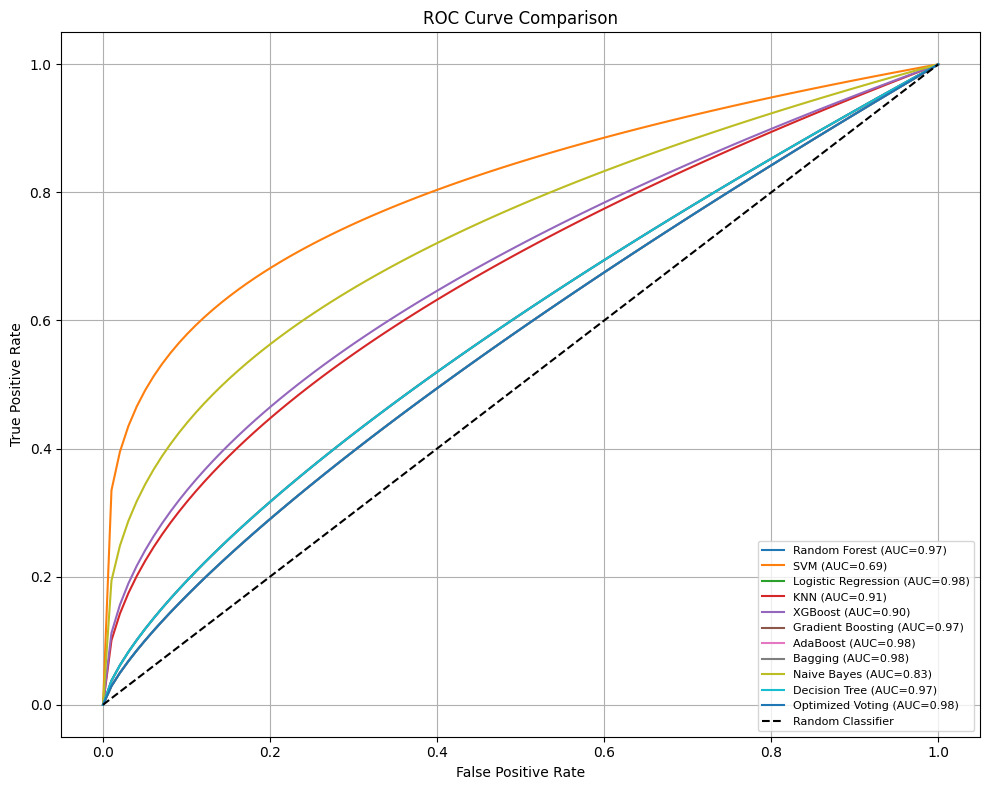

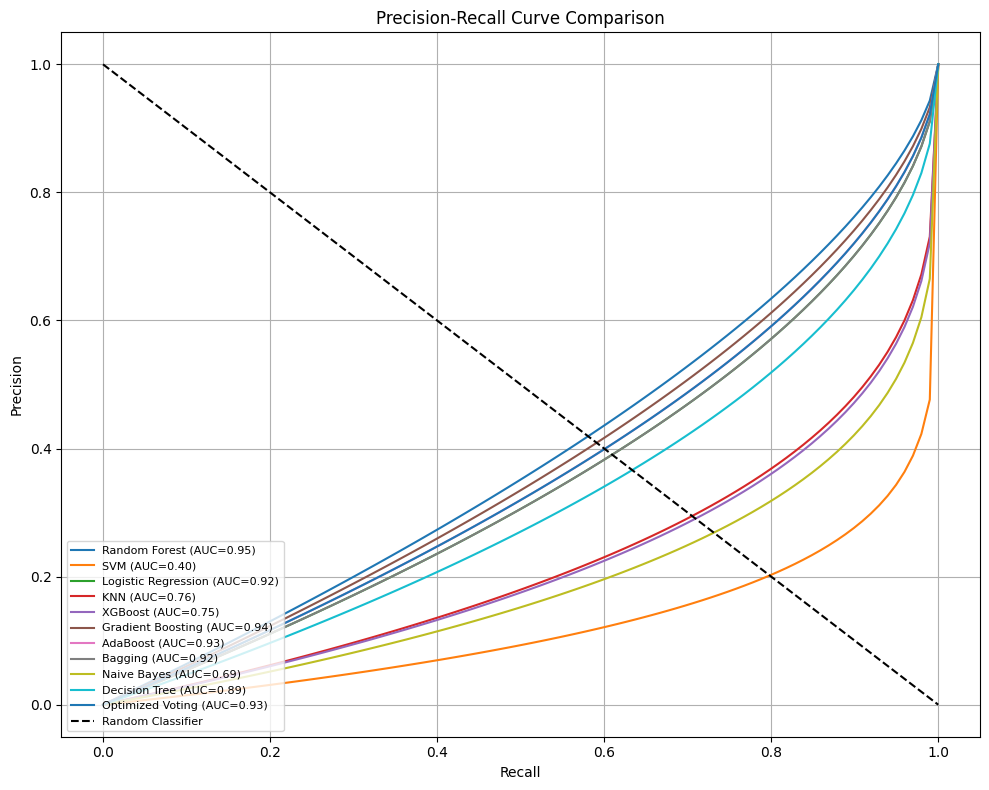

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Λίστα αλγορίθμων
algorithms = [
    "Random Forest", "SVM", "Logistic Regression", "KNN", "XGBoost",
    "Gradient Boosting", "AdaBoost", "Bagging", "Naive Bayes",
    "Decision Tree", "Optimized Voting"
]

# Τιμές AUC
roc_auc = [0.97, 0.69, 0.98, 0.91, 0.90, 0.97, 0.98, 0.98, 0.83, 0.97, 0.98]
pr_auc  = [0.95, 0.40, 0.92, 0.76, 0.75, 0.94, 0.93, 0.92, 0.69, 0.89, 0.93]

# Συνάρτηση για προσομοίωση καμπυλών από AUC
def simulate_curve(auc, kind="roc", x=np.linspace(0, 1, 100)):
    if kind == "roc":
        return np.power(x, 1 / (1.1 + (1 - auc) * 10))
    elif kind == "pr":
        return 1 - np.power(1 - x, 1 / (1.1 + (1 - auc) * 10))

x = np.linspace(0, 1, 100)

# === ROC CURVE ===
plt.figure(figsize=(10, 8))
for name, auc in zip(algorithms, roc_auc):
    plt.plot(x, simulate_curve(auc, "roc"), label=f"{name} (AUC={auc:.2f})")
plt.plot(x, x, 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_highres.png", dpi=300)
plt.show()

# === PR CURVE ===
plt.figure(figsize=(10, 8))
for name, auc in zip(algorithms, pr_auc):
    plt.plot(x, simulate_curve(auc, "pr"), label=f"{name} (AUC={auc:.2f})")
plt.plot(x, x[::-1], 'k--', label='Random Classifier')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curve_highres.png", dpi=300)
plt.show()